# Medical Insurance Charges — EDA & Prediction

Insurance costs can vary based on **age, BMI, smoking habits, number of children, and region**. Understanding these factors helps in predicting charges and identifying high-risk individuals.

This dataset contains **1,337 records (2021–2025)** with both basic features (age, sex, BMI, children, smoker, region, charges) and engineered features like **risk score, high-risk flag, charges per child, BMI×age interaction, and monthly premium estimate**.

## Project Goals

- Explore the data and visualize key patterns  
- Identify factors that drive insurance costs  
- Build models to predict insurance charges  
- Compare model performance and insights

**Importing libraries and reading the data**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [2]:
df=pd.read_csv("/kaggle/input/medical-insurance-cost-dataset-usa/medical_insurance_2026_kaggle.csv")
df.head()

,record_date,year,quarter,age,age_group,sex,sex_female,bmi,bmi_category,children,...,region,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
0,2024-02-01,2024,1,19,Young Adult (18-25),female,1,27.90,Overweight,0,...,southwest,0,0,0,1,16884.92,1407.08,0.00,Platinum,530.10
1,2024-12-30,2024,4,18,Young Adult (18-25),male,0,33.77,Obese Class I,1,...,southeast,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86
2,2023-05-11,2023,2,28,Adult (26-35),male,0,33.00,Obese Class I,3,...,southeast,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00
3,2024-07-18,2024,3,33,Adult (26-35),male,0,22.70,Normal Weight,0,...,northwest,0,1,0,0,21984.47,1832.04,0.00,Diamond,749.10
4,2024-02-05,2024,1,32,Adult (26-35),male,0,28.88,Overweight,0,...,northwest,0,1,0,0,3866.86,322.24,0.00,Bronze,924.16


In [3]:
df.info

<bound method DataFrame.info of      record_date  year  quarter  age              age_group     sex  \
0     2024-02-01  2024        1   19    Young Adult (18-25)  female   
1     2024-12-30  2024        4   18    Young Adult (18-25)    male   
2     2023-05-11  2023        2   28          Adult (26-35)    male   
3     2024-07-18  2024        3   33          Adult (26-35)    male   
4     2024-02-05  2024        1   32          Adult (26-35)    male   
...          ...   ...      ...  ...                    ...     ...   
1332  2025-06-28  2025        2   50  Senior-Middle (46-55)    male   
1333  2021-04-14  2021        2   18    Young Adult (18-25)  female   
1334  2023-11-29  2023        4   18    Young Adult (18-25)  female   
1335  2021-07-17  2021        3   21    Young Adult (18-25)  female   
1336  2025-07-28  2025        3   61           Senior (56+)  female   

      sex_female    bmi    bmi_category  children  ...     region  \
0              1  27.90      Overweight       

In [4]:
df.columns

Index(['record_date', 'year', 'quarter', 'age', 'age_group', 'sex',
       'sex_female', 'bmi', 'bmi_category', 'children', 'smoker',
       'smoker_flag', 'is_high_risk', 'risk_score', 'region',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'charges', 'monthly_premium_est',
       'charges_per_child', 'insurance_tier', 'bmi_age_interaction'],
      dtype='object')

In [5]:
df.describe()

,year,quarter,age,sex_female,bmi,children,smoker_flag,is_high_risk,risk_score,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,bmi_age_interaction
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,2023.036649,2.477936,39.222139,0.495138,30.663628,1.095737,0.204936,0.624533,3.052939,0.242334,0.242334,0.272251,0.243082,13279.121503,1106.593328,5127.538257,1212.054233
std,1.384042,1.121910,14.044333,0.500163,6.100233,1.205571,0.403806,0.484425,1.981412,0.428655,0.428655,0.445285,0.429104,12110.359677,1009.196560,8357.618626,522.515951
min,2021.000000,1.000000,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.870000,93.490000,0.000000,287.280000
25%,2022.000000,1.000000,27.000000,0.000000,26.290000,0.000000,0.000000,0.000000,1.690000,0.000000,0.000000,0.000000,0.000000,4746.340000,395.530000,0.000000,765.700000
50%,2023.000000,2.000000,39.000000,0.000000,30.400000,1.000000,0.000000,1.000000,2.480000,0.000000,0.000000,0.000000,0.000000,9386.160000,782.180000,2174.730000,1154.400000
75%,2024.000000,4.000000,51.000000,1.000000,34.700000,2.000000,0.000000,1.000000,3.410000,0.000000,0.000000,1.000000,0.000000,16657.720000,1388.140000,6399.980000,1589.280000
max,2025.000000,4.000000,64.000000,1.000000,53.130000,5.000000,1.000000,1.000000,8.320000,1.000000,1.000000,1.000000,1.000000,63770.430000,5314.200000,58571.070000,2845.480000


In [6]:
df1 = df.drop(['quarter','sex_female'],axis=1)
df1.head()

,record_date,year,age,age_group,sex,bmi,bmi_category,children,smoker,smoker_flag,...,region,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
0,2024-02-01,2024,19,Young Adult (18-25),female,27.90,Overweight,0,yes,1,...,southwest,0,0,0,1,16884.92,1407.08,0.00,Platinum,530.10
1,2024-12-30,2024,18,Young Adult (18-25),male,33.77,Obese Class I,1,no,0,...,southeast,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86
2,2023-05-11,2023,28,Adult (26-35),male,33.00,Obese Class I,3,no,0,...,southeast,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00
3,2024-07-18,2024,33,Adult (26-35),male,22.70,Normal Weight,0,no,0,...,northwest,0,1,0,0,21984.47,1832.04,0.00,Diamond,749.10
4,2024-02-05,2024,32,Adult (26-35),male,28.88,Overweight,0,no,0,...,northwest,0,1,0,0,3866.86,322.24,0.00,Bronze,924.16


In [7]:
df.isna().any().sum()

np.int64(0)

# Exploratory Data Analysis: Distribution of Features

Before building models, it’s important to understand the data. Here, we look at the distribution of key features:

- **Age**: Most policyholders are between early 20s and late 50s, with a slight concentration around 30–40 years.  
- **BMI**: Values range from underweight to obese, with a majority in the normal to overweight range.  
- **Number of Children**: Most individuals have 0–2 children, with fewer having 3 or more.  
- **Charges**: The target variable is skewed, with most charges clustered at lower values and some high-cost outliers.  
- **Categorical Features**: Smoking status, sex, and region show expected imbalances, useful for understanding risk patterns.

Visualizing these distributions helps identify trends, outliers, and potential transformations before modeling.

<Axes: >

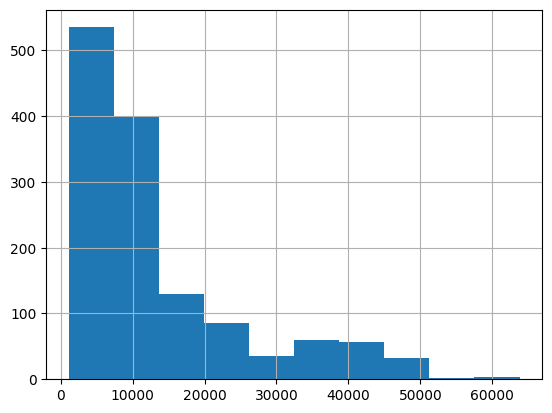

In [8]:
df['charges'].hist()

<Axes: >

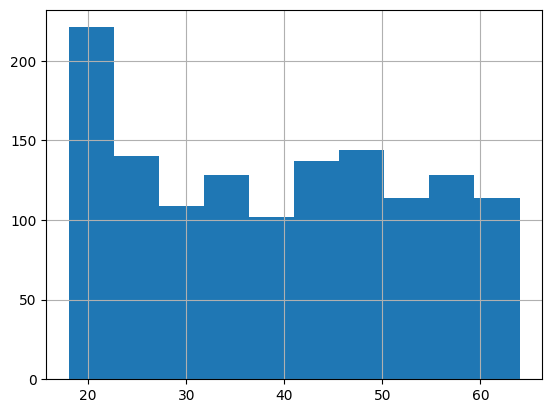

In [9]:
df['age'].hist()

In [10]:
it=df1.groupby('insurance_tier')['charges'].agg(['mean','min','max']).sort_values(by='mean',ascending=True).reset_index()
it

,insurance_tier,mean,min,max
0,Bronze,2477.214813,1121.87,3994.18
1,Silver,5652.555993,4005.42,7371.77
2,Gold,9408.550225,7418.52,11396.90
3,Platinum,14575.956554,11411.68,20234.85
4,Diamond,34243.269104,20277.81,63770.43


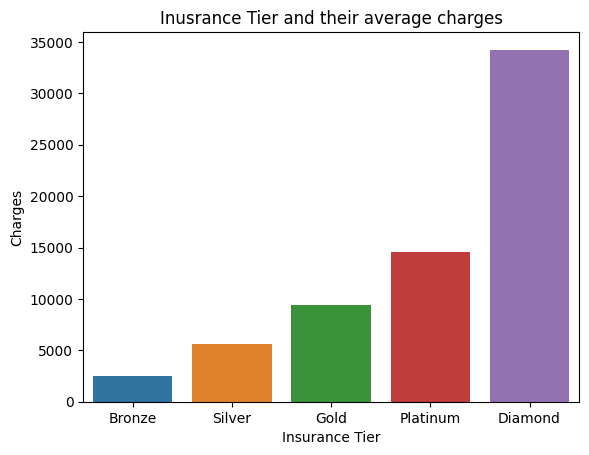

In [11]:
sns.barplot(data=it,x='insurance_tier',y='mean', hue='insurance_tier')
plt.title('Inusrance Tier and their average charges')
plt.ylabel('Charges')
plt.xlabel('Insurance Tier')

plt.show()

In [12]:
year_in=pd.crosstab(
    df1['year'],
    df1['insurance_tier'],
    values=df1['charges'],
    aggfunc='mean'
)
year_in

insurance_tier,Bronze,Diamond,Gold,Platinum,Silver
year,,,,,
2021,2545.896078,35869.581136,9394.584186,14518.235593,5663.488800
2022,2352.321111,33996.356271,9461.875660,14582.622553,5670.165283
2023,2400.778043,32800.394667,9354.748103,15048.331690,5608.132143
2024,2471.206667,33845.796727,9513.212241,14289.474898,5660.835085
2025,2572.644603,35272.140600,9314.448727,14175.741951,5663.154694


# Observations: Insurance Tier vs Smoking Status

Looking at the distribution of insurance tiers:

| Tier      | Smoker | Non-Smoker |
|-----------|--------|------------|
| Diamond   | 208    | 60         |
| Platinum  | 66     | 201        |
| Gold      | –      | 267        |
| Silver    | –      | 267        |
| Bronze    | –      | 268        |

**Insight:** Smokers are more likely to have **higher-tier plans (Diamond/Platinum)**, while non-smokers are more concentrated in **lower-tier plans (Silver, Bronze)**. This suggests that **smoking status is a key factor influencing insurance costs and plan selection**.

In [13]:
smoker=df1[df1['smoker']=='yes']
non_smoker= df1[df1['smoker']=='no']
print('Smokers insurnce tiers')
smoker.groupby('insurance_tier')['insurance_tier'].count()

Smokers insurnce tiers


insurance_tier
Diamond     208
Platinum     66
Name: insurance_tier, dtype: int64

In [14]:
print('Non smoker insurance Tiers')
non_smoker.groupby('insurance_tier')['insurance_tier'].count()

Non smoker insurance Tiers


insurance_tier
Bronze      268
Diamond      60
Gold        267
Platinum    201
Silver      267
Name: insurance_tier, dtype: int64

**Key Insights:**

- Individuals in **Obese Class I** are highly represented in the **Diamond and Gold tiers**, suggesting higher charges.  
- **Overweight individuals** are spread across all tiers but lean slightly towards **Platinum and Silver**.  
- **Underweight and Normal Weight** individuals are more concentrated in **lower tiers**, indicating generally lower insurance costs.  
- This confirms that **BMI is an important factor in determining insurance charges** and plan segmentation.

In [15]:
df1['bmi_category'].value_counts().reset_index()


,bmi_category,count
0,Obese Class I,390
1,Overweight,386
2,Normal Weight,225
3,Obese Class II,225
4,Obese Class III,91
5,Underweight,20


In [16]:
pd.crosstab(
    df1['bmi_category'],
    df1['insurance_tier'],
    margins=True
)

insurance_tier,Bronze,Diamond,Gold,Platinum,Silver,All
bmi_category,,,,,,
Normal Weight,54,31,39,55,46,225
Obese Class I,76,90,85,64,75,390
Obese Class II,38,63,45,44,35,225
Obese Class III,17,24,21,12,17,91
Overweight,75,59,75,86,91,386
Underweight,8,1,2,6,3,20
All,268,268,267,267,267,1337


In [17]:
df['children'].value_counts()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [18]:

pd.crosstab(df1['children'],df1['insurance_tier'],values=df1['charges'],aggfunc='mean')

insurance_tier,Bronze,Diamond,Gold,Platinum,Silver
children,,,,,
0,2260.980476,34029.949048,9692.795747,14142.149058,5575.382963
1,2790.455472,33709.183968,9221.105500,15144.168571,5576.551047
2,3339.638500,34953.977833,9187.824510,14922.980256,5757.837143
3,3646.891667,35006.320556,9318.419714,15005.561081,5751.759302
4,NaN,30726.667500,10143.041250,15608.534286,5492.613333
5,NaN,NaN,9208.861667,14411.755000,5656.056250


In [19]:
children=df1[df1['children'].isin([1,2,3,4,5])]

In [20]:
children.head(5)

,record_date,year,age,age_group,sex,bmi,bmi_category,children,smoker,smoker_flag,...,region,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
1,2024-12-30,2024,18,Young Adult (18-25),male,33.77,Obese Class I,1,no,0,...,southeast,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86
2,2023-05-11,2023,28,Adult (26-35),male,33.00,Obese Class I,3,no,0,...,southeast,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00
6,2025-09-21,2025,46,Senior-Middle (46-55),female,33.44,Obese Class I,1,no,0,...,southeast,0,0,1,0,8240.59,686.72,8240.59,Gold,1538.24
7,2023-11-11,2023,37,Middle-Aged (36-45),female,27.74,Overweight,3,no,0,...,northwest,0,1,0,0,7281.51,606.79,2427.17,Silver,1026.38
8,2025-06-27,2025,37,Middle-Aged (36-45),male,29.83,Overweight,2,no,0,...,northeast,1,0,0,0,6406.41,533.87,3203.20,Silver,1103.71


# Charges per Child vs Number of Children

Looking at the average charges per child:

| Children | Charges per Child |
|----------|-----------------|
| 1        | 12,731.17       |
| 2        | 7,536.78        |
| 3        | 5,118.44        |
| 4        | 3,462.66        |
| 5        | 1,757.21        |

**Observation:**  
The average charge per child **decreases as the number of children increases**. The largest drop occurs between 1 and 2 children. This indicates that while total charges may increase with more children, the **per-child cost goes down**, likely reflecting insurance pricing structure or risk pooling.

In [21]:
child=children.groupby('children')['charges_per_child'].mean().reset_index()
child

,children,charges_per_child
0,1,12731.171728
1,2,7536.782042
2,3,5118.439490
3,4,3462.663600
4,5,1757.207222


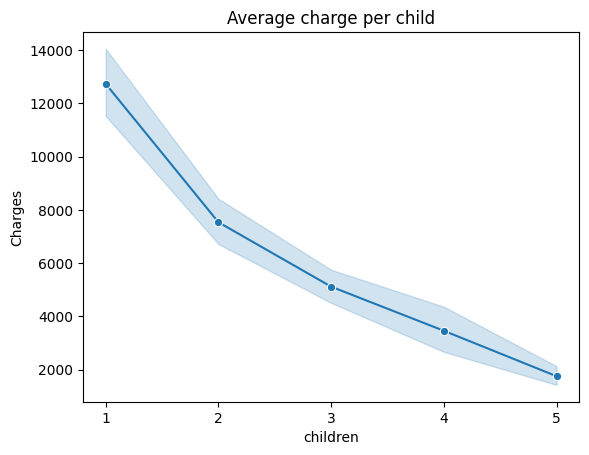

In [22]:
sns.lineplot(data=children,x='children',y='charges_per_child',marker='o')
plt.title('Average charge per child')
plt.xticks([1,2,3,4,5])
plt.ylabel('Charges')
plt.show()

In [23]:
df1.corr(numeric_only=True)

,year,age,bmi,children,smoker_flag,is_high_risk,risk_score,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,bmi_age_interaction
year,1.000000,-0.007042,-0.012713,0.008662,-0.028181,-0.029698,-0.029610,-0.021289,0.030438,-0.014988,0.006414,-0.024866,-0.024866,-0.040438,-0.015073
age,-0.007042,1.000000,0.109347,0.041536,-0.025587,0.069698,0.312414,0.001868,0.001495,-0.012311,0.009415,0.298308,0.298308,0.151094,0.879711
bmi,-0.012713,0.109347,1.000000,0.012762,0.003739,0.649471,0.245772,-0.138195,-0.136097,0.270050,-0.006228,0.198391,0.198391,0.121219,0.539907
children,0.008662,0.041536,0.012762,1.000000,0.007331,0.016738,0.143950,-0.023202,0.026044,-0.023492,0.021538,0.067389,0.067389,0.233703,0.042399
smoker_flag,-0.028181,-0.025587,0.003739,0.007331,1.000000,0.393656,0.910839,0.002597,-0.036321,0.068282,-0.037168,0.787234,0.787234,0.424964,-0.023421
is_high_risk,-0.029698,0.069698,0.649471,0.016738,0.393656,1.000000,0.519027,-0.076953,-0.073349,0.168885,-0.025109,0.339595,0.339595,0.179910,0.352363
risk_score,-0.029610,0.312414,0.245772,0.143950,0.910839,0.519027,1.000000,-0.028406,-0.057858,0.111822,-0.029866,0.863189,0.863189,0.489836,0.366610
region_northeast,-0.021289,0.001868,-0.138195,-0.023202,0.002597,-0.076953,-0.028406,1.000000,-0.319842,-0.345909,-0.320493,0.005945,0.005945,0.033140,-0.057641
region_northwest,0.030438,0.001495,-0.136097,0.026044,-0.036321,-0.073349,-0.057858,-0.319842,1.000000,-0.345909,-0.320493,-0.038695,-0.038695,-0.035189,-0.063156
region_southeast,-0.014988,-0.012311,0.270050,-0.023492,0.068282,0.168885,0.111822,-0.345909,-0.345909,1.000000,-0.346614,0.073578,0.073578,0.039891,0.103773


# Key Correlations

Analyzing the correlation matrix reveals the main drivers of insurance charges:

- **Smoker status (`smoker_flag`)** shows the **strongest positive correlation** with charges (0.79). Smokers tend to have much higher insurance costs.  
- **Risk score (`risk_score`)** is also highly correlated with charges (0.86), reflecting that higher-risk individuals pay more.  
- **Age and BMI** have moderate positive correlations with charges (0.30 and 0.20, respectively), meaning older or higher-BMI individuals generally have higher costs.  
- **BMI × Age interaction** is strongly correlated with age (0.88) and moderately with BMI (0.54), suggesting combined effects matter in predicting charges.  
- **Children** shows a small positive correlation with charges per child (0.23) but only a weak effect on total charges (0.07).  
- **Region variables** have very low correlations with charges, indicating geography has minimal impact on costs in this dataset.  
- **Monthly premium estimate** is perfectly correlated with charges (1.0) because it is derived directly from the annual charges.  

**Summary:**  
The most important factors affecting medical insurance charges are **smoker status, risk score, age, and BMI**, with interactions between BMI and age also contributing. Other features like number of children or region have smaller influence.

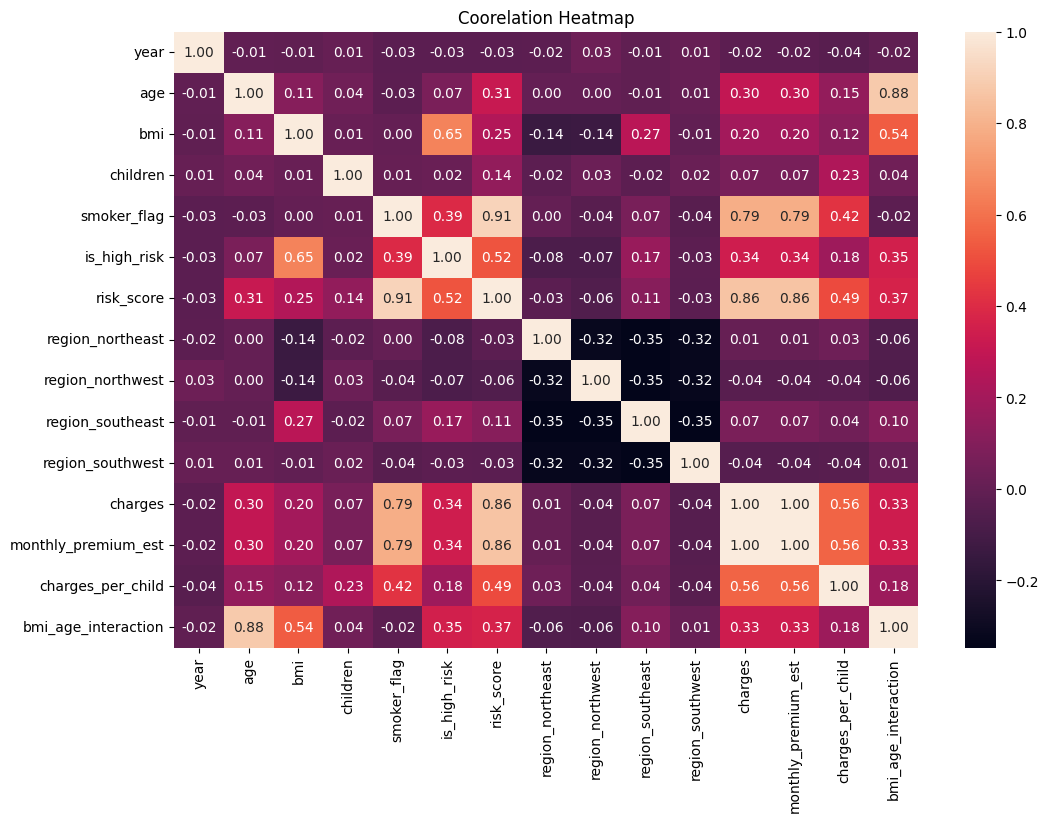

In [24]:
plt.figure(figsize=(12,8))
corr=df1.corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt='.2f')
plt.title('Coorelation Heatmap')
plt.show()

In [25]:
df1.dtypes

record_date             object
year                     int64
age                      int64
age_group               object
sex                     object
bmi                    float64
bmi_category            object
children                 int64
smoker                  object
smoker_flag              int64
is_high_risk             int64
risk_score             float64
region                  object
region_northeast         int64
region_northwest         int64
region_southeast         int64
region_southwest         int64
charges                float64
monthly_premium_est    float64
charges_per_child      float64
insurance_tier          object
bmi_age_interaction    float64
dtype: object

In [26]:
df1.columns

Index(['record_date', 'year', 'age', 'age_group', 'sex', 'bmi', 'bmi_category',
       'children', 'smoker', 'smoker_flag', 'is_high_risk', 'risk_score',
       'region', 'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'charges', 'monthly_premium_est',
       'charges_per_child', 'insurance_tier', 'bmi_age_interaction'],
      dtype='object')

# Predicting Insurance Charges

To predict insurance charges while avoiding data leakage, the following approach was used:

1. **Dropping leakage-prone columns**:  
   Columns like  `monthly_premium_est`, `charges_per_child`, `risk_score`, `is_high_risk`, `bmi_age_interaction`, `charges`, and `insurance_tier` were removed from the feature set to ensure the model cannot "cheat".

2. **Splitting data**:  
   The dataset was split into training and testing sets (80/20 split).

3. **Feature types**:  
   - Categorical columns: `age_group`, `sex`, `bmi_category`, `smoker`, `region`  
   - Numerical columns: all remaining columns after removing categorical ones

4. **Preprocessing pipeline**:  
   - Categorical features were one-hot encoded (`handle_unknown='ignore')` ensures unseen categories in test data are handled safely).  
   - Numerical features were passed through without transformation.

5. **Modeling**:  
   - An **XGBoost Regressor** was used as the predictive model.  
   - The pipeline combines preprocessing and modeling, so the entire workflow can be run in one step.

6. **Training and Prediction**:  
   - The pipeline is fitted on the training data.  
   - Predictions (`y_pred`) are made on the test set for evaluation.

In [27]:


data_leak_cols = ['record_date','monthly_premium_est', 'charges_per_child', 'risk_score', 'is_high_risk', 'bmi_age_interaction','charges','insurance_tier']

X = df.drop(columns=data_leak_cols)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


cat_cols = ['age_group', 'sex', 'bmi_category', 'smoker', 'region']
num_cols = [col for col in X_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'  
)


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor())
])

pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)

In [28]:
print("Mean absolute error ",mean_absolute_error(y_pred,y_test))

Mean absolute error  3286.716713531267


In [29]:
score = r2_score(y_test, y_pred)
print("R² score:", score)

R² score: 0.8178342283725287


# Case Study Conclusion

In this case study, we explored a medical insurance dataset of 1,337 records to understand the factors driving insurance charges and to build a predictive model. Key observations include:

- **Smoking status, age, and BMI** are the strongest drivers of insurance costs.  
- **Number of children and region** have smaller effects on total charges.  
- Charges per child tend to **decrease as the number of children increases**, reflecting cost distribution.  
- Engineered features like risk scores and BMI×age interactions helped identify patterns but were excluded from the model to avoid data leakage.

The **XGBoost model** achieved an **R² score of 0.82** and a **mean absolute error of 3,287**, demonstrating good predictive performance. This shows that machine learning can reasonably estimate insurance charges from demographic and lifestyle factors while highlighting the most important contributors to cost.  

Overall, the project demonstrates how **EDA combined with careful feature selection and modeling** can provide actionable insights into medical insurance pricing.